**Group Name(s)**: Chloe Barker, Samson Akomolafe, Tracy Dower, Turner 'Blake' Armstrong

# File Organization and Database Mangement Project 
In the following notebook, our team demonstrates how to query and visualize data from our water quality database. The goal is to quickly identify contaminants and highlight areas with elevated levels of harmful components, helping researchers focus on regions where water quality may impact public health.

## 1. Build GIS boundaries for Mapping and Visualization

In [ ]:
import mysql.connector

cnx = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Ricky6051",
    database="welldata2",
    port=3306
)

print("Connected!")


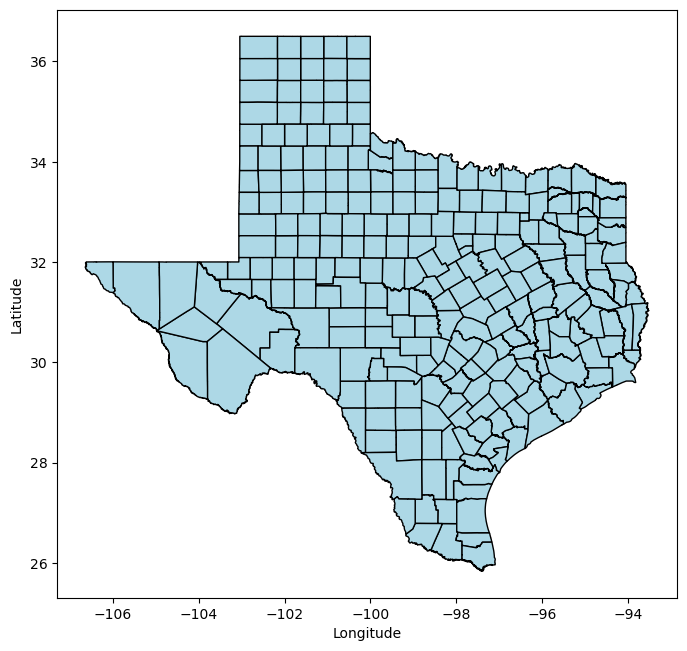

In [1]:
import geopandas as gpd


counties = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip")

# Filter for Texas counties using the STATEFP column and FIPS code of 48
tx_counties = counties[counties['STATEFP'] == '48']

# Create a plot
ax = tx_counties.plot(figsize=(8, 8), color='lightblue', edgecolor='black')

# Label axes
ax.set_xlabel("Longitude");
ax.set_ylabel("Latitude");

## 2. Create SQL Engine and Queries

In [2]:
from sqlalchemy import create_engine, text
import json
import urllib.parse
import pandas as pd

# Load JSON config
with open('db_config.json', 'r') as f:
    config = json.load(f)

# URL encoded password in case it has special characters
config['password'] = urllib.parse.quote_plus(config['password'])

# Create connection string
conn_str = f"mysql+pymysql://{config['user']}:{config['password']}@{config['host']}:{config['port']}/{config['database']}"

# Create SQLAlchemy engine
engine = create_engine(conn_str)

# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT DATABASE();"))
    print("Connected to database:", result.fetchone()[0])


# List of contaminants to query
contaminants = ["lead", "arsenic","mercury","fluoride","lithium","uranium","radium-226","radium-228","chromium","manganese"]
dfs_avg = []

# Store the procedure here so that not everyone's database has to have the same procedure created
for contaminant in contaminants:
    avg_query = text(f"""
        SELECT
            CountyName AS County,
            lower(Component),
            ParameterUnit,
            AVG(ParameterValue) AS AvgValue 
        FROM (
            SELECT
                c.CountyName,
                wqp.ConstituentName AS Component,
                wqp.WaterQualityParameterCode AS ParameterCode,
                wqp.ParameterUnitOfMeasure AS ParameterUnit,
                wqd.ParameterValue,
                wh.SampleDate,
                ROW_NUMBER() OVER (
                PARTITION BY c.CountyName, lower(wqp.ConstituentName)
                ORDER BY wh.SampleDate DESC
            ) AS rn
            FROM waterqualitydetail wqd
            JOIN waterqualityheader wh ON wqd.WaterQualityHeaderId = wh.WaterQualityHeaderId
            JOIN welldata wd ON wh.StateWellId = wd.StateWellId
            JOIN welllocation wl ON wd.StateWellId = wl.StateWellId
            JOIN county c ON wl.CountyID = c.CountyID
            JOIN waterqualityparameters wqp ON wqd.WaterQualityParameterId = wqp.WaterQualityParameterID
            WHERE wqp.ConstituentName = :contaminant
            ) AS sub
        WHERE rn <= 4
        GROUP BY CountyName, lower(Component), ParameterUnit
        ORDER BY CountyName, lower(Component);
""")
    
    with engine.connect() as conn:
        df_avg = pd.read_sql(avg_query, conn, params={"contaminant": contaminant})
        df_avg["contaminant"] = contaminant
        dfs_avg.append(df_avg)

long_df_avg = pd.concat(dfs_avg, ignore_index=True)
print(long_df_avg)

# Pivot to wide format dynamically
wide_values = long_df_avg.pivot(index="County", columns="contaminant", values="AvgValue").reset_index()
rename_dict = {c: f"{c}_avg" for c in contaminants if c in wide_values.columns}
wide_values = wide_values.rename(columns=rename_dict)

# Pivot the units dynamically
wide_units = long_df_avg.pivot(index="County", columns="contaminant", values="ParameterUnit").reset_index()
# Rename the columns to include "_unit" suffix
wide_units = wide_units.rename(columns={c: f"{c}_unit" for c in wide_units.columns if c != "County"})

# Merge the values and units
wide_df_avg = wide_values.merge(wide_units, on="County", how="left")

wide_df_avg.head(20)


Connected to database: welldata2
         County lower(Component) ParameterUnit  AvgValue contaminant
0      ANDERSON             lead          UG/L    1.0100        lead
1       ANDREWS             lead          UG/L    2.2500        lead
2      ANGELINA             lead          UG/L    1.0000        lead
3       ARANSAS             lead          UG/L    1.0050        lead
4     ARMSTRONG             lead          UG/L    5.0000        lead
...         ...              ...           ...       ...         ...
2457       WISE        manganese          UG/L   22.4750   manganese
2458       WOOD        manganese          UG/L   15.3725   manganese
2459     YOAKUM        manganese          UG/L    3.5750   manganese
2460     ZAPATA        manganese          UG/L   56.3500   manganese
2461     ZAVALA        manganese          UG/L   37.5675   manganese

[2462 rows x 5 columns]


contaminant,County,arsenic_avg,chromium_avg,fluoride_avg,lead_avg,lithium_avg,manganese_avg,mercury_avg,radium-226_avg,radium-228_avg,...,arsenic_unit,chromium_unit,fluoride_unit,lead_unit,lithium_unit,manganese_unit,mercury_unit,radium-226_unit,radium-228_unit,uranium_unit
0,ANDERSON,1.0000,1.1325,0.166825,1.0100,4.3950,4.6650,0.20,0.98500,1.17500,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
1,ANDREWS,19.1500,2.4025,4.295000,2.2500,147.3000,2.2500,0.20,0.57500,1.07500,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
2,ANGELINA,1.0000,2.8300,0.755750,1.0000,27.9500,16.1625,0.20,0.98000,0.90000,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
3,ARANSAS,20.1500,1.5825,0.250000,1.0050,14.6250,56.8000,0.20,1.00000,1.00000,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
4,ARCHER,NaN,NaN,1.365000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,MG/L,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ARMSTRONG,5.6150,5.0000,3.022500,5.0000,128.4500,7.1250,0.20,1.00000,1.00000,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
6,ATASCOSA,1.0000,3.1375,0.334050,1.0000,47.7750,51.5250,0.20,0.98000,1.12500,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
7,AUSTIN,1.4875,1.1325,0.285000,1.1950,31.6225,2.8675,0.20,1.00000,1.00000,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
8,BAILEY,2.1750,1.3700,0.918750,1.0000,48.7500,1.0000,0.20,0.60000,1.12500,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L
9,BANDERA,1.0000,8.2125,2.620000,1.0000,56.7750,3.7525,0.20,1.75000,2.10000,...,UG/L,UG/L,MG/L,UG/L,UG/L,UG/L,UG/L,PC/L,PC/L,UG/L


## 3. Merge the data for vizualization

In [3]:
# Pulling out the data that we need for the merge
tx_counties.loc[:, 'NAME'] = tx_counties['NAME'].str.upper()
wide_df_avg.loc[:, 'County'] = wide_df_avg['County'].str.upper()

# Merge
tx_merged = tx_counties.merge(wide_df_avg, left_on='NAME', right_on='County', how='left')

# Drop redundant county column
tx_merged = tx_merged.drop(columns=['County'])

In [4]:
print("Shape:", tx_merged.shape)
print(tx_merged.head())

Shape: (254, 39)
  STATEFP COUNTYFP  COUNTYNS  GEOID         GEOIDFQ       NAME  \
0      48      327  01383949  48327  0500000US48327     MENARD   
1      48      189  01383880  48189  0500000US48189       HALE   
2      48      011  01383791  48011  0500000US48011  ARMSTRONG   
3      48      057  01383814  48057  0500000US48057    CALHOUN   
4      48      077  01383824  48077  0500000US48077       CLAY   

           NAMELSAD LSAD CLASSFP  MTFCC  ... arsenic_unit chromium_unit  \
0     Menard County   06      H1  G4020  ...         UG/L          UG/L   
1       Hale County   06      H1  G4020  ...         UG/L          UG/L   
2  Armstrong County   06      H1  G4020  ...         UG/L          UG/L   
3    Calhoun County   06      H1  G4020  ...         UG/L          UG/L   
4       Clay County   06      H1  G4020  ...         UG/L          UG/L   

  fluoride_unit lead_unit  lithium_unit  manganese_unit mercury_unit  \
0          MG/L      UG/L          UG/L            UG/L        

## 4. Vizualize the data

In [5]:
import folium
from folium.features import GeoJsonTooltip

# Choose contaminant
contaminant = "mercury" # UPDATE THIS FOR A NEW MAP

# Columns
value_col = f"{contaminant.lower()}_avg"
unit_col = f"{contaminant.lower()}_unit"

# Get the unit dynamically
unit = tx_merged[unit_col].dropna().unique()[0] if not tx_merged[unit_col].dropna().empty else ""

# Create legend title with the correct unit
legend_title = f"Average {contaminant.capitalize()} Level ({unit})"

# Initialize map
m = folium.Map(location=[31.0, -99.0], zoom_start=6)

# Choropleth
folium.Choropleth(
    geo_data=tx_merged.__geo_interface__,
    name=f"{contaminant} choropleth",
    data=tx_merged,
    columns=["NAME", value_col],
    key_on="feature.properties.NAME",
    fill_color="OrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name=legend_title
).add_to(m)

# Interactive tooltip showing value and unit
folium.GeoJson(
    tx_merged.__geo_interface__,
    name="County Data",
    tooltip=GeoJsonTooltip(
        fields=["NAME", value_col, unit_col],
        aliases=["County:", f"{contaminant.capitalize()} Level:", "Unit:"],
        localize=True
    )
).add_to(m)

# Save map
file_name = f"texas_{contaminant.lower()}_map.html"
m.save(file_name)

In [14]:
import matplotlib.pyplot as plt

def plot_contaminant_map(contaminant, wide_df=wide_df_avg, gdf=tx_counties):
    value_col = f"{contaminant}_avg"
    unit_col = f"{contaminant}_unit"

    if value_col not in wide_df.columns:
        raise ValueError(f"Contaminant '{contaminant}' not found. "
                         f"Available: {[c.replace('_avg','') for c in wide_df.columns if c.endswith('_avg')]}")

    # Merge map data + contaminant averages
    merged = gdf.merge(wide_df, left_on="NAME", right_on="County", how="left")

    # Extract unit (if available)
    unit = merged[unit_col].dropna().unique()
    unit = unit[0] if len(unit) > 0 else ""

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    merged.plot(column=value_col,
                ax=ax,
                legend=True,
                cmap="viridis",
                missing_kwds={"color": "lightgrey", "hatch": "//", "label": "No data"},
                edgecolor="black",
                linewidth=0.3)

    ax.set_title(f"Texas County Average {contaminant.capitalize()} Levels\nUnit: {unit}", fontsize=16)
    ax.set_axis_off()
    plt.show()

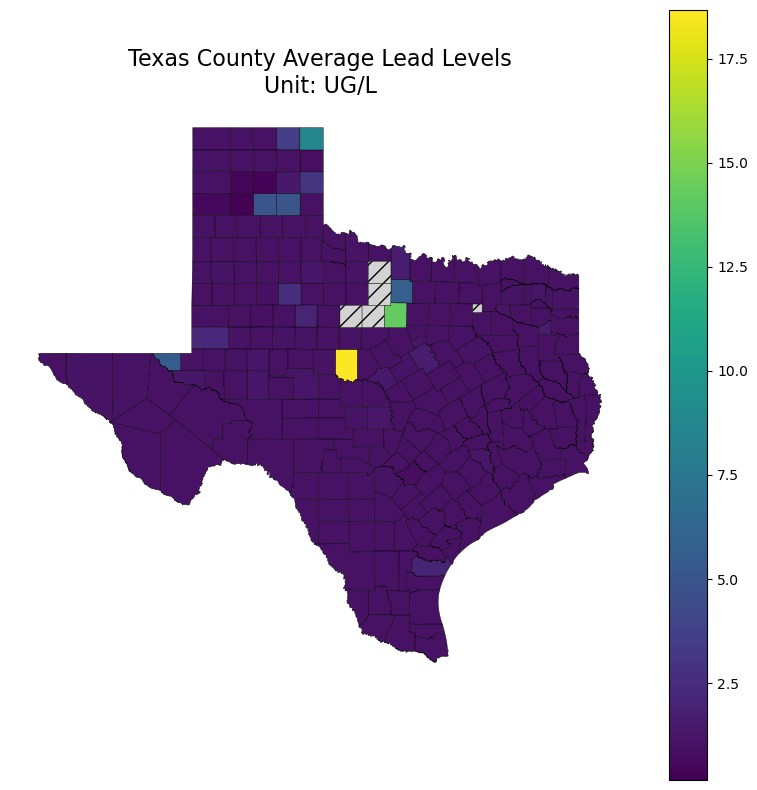

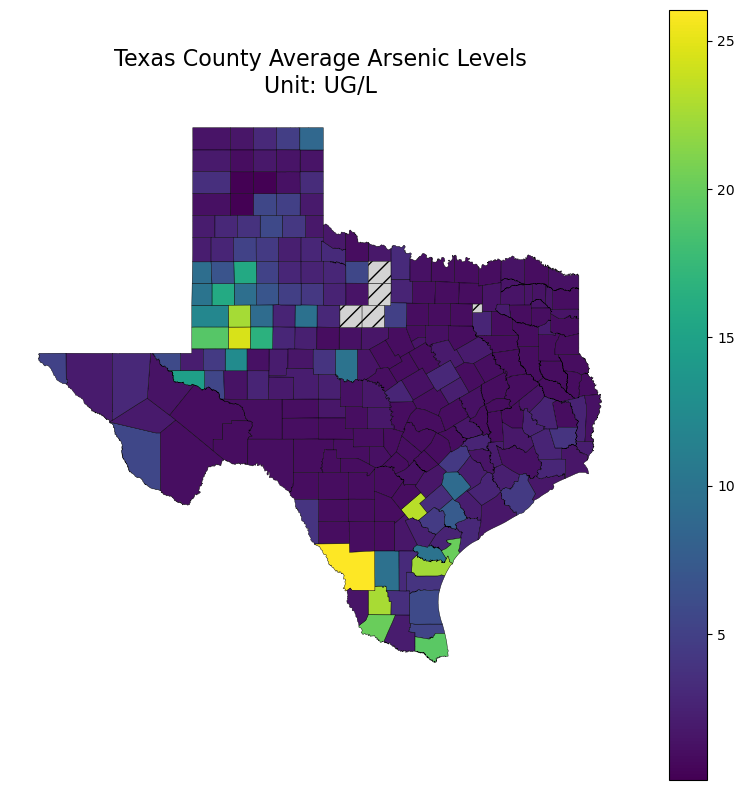

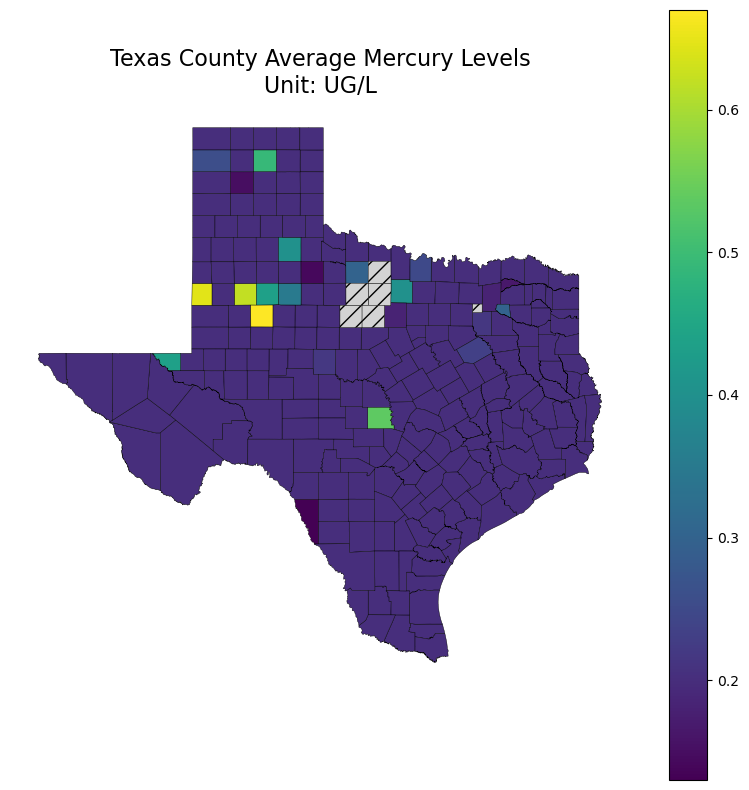

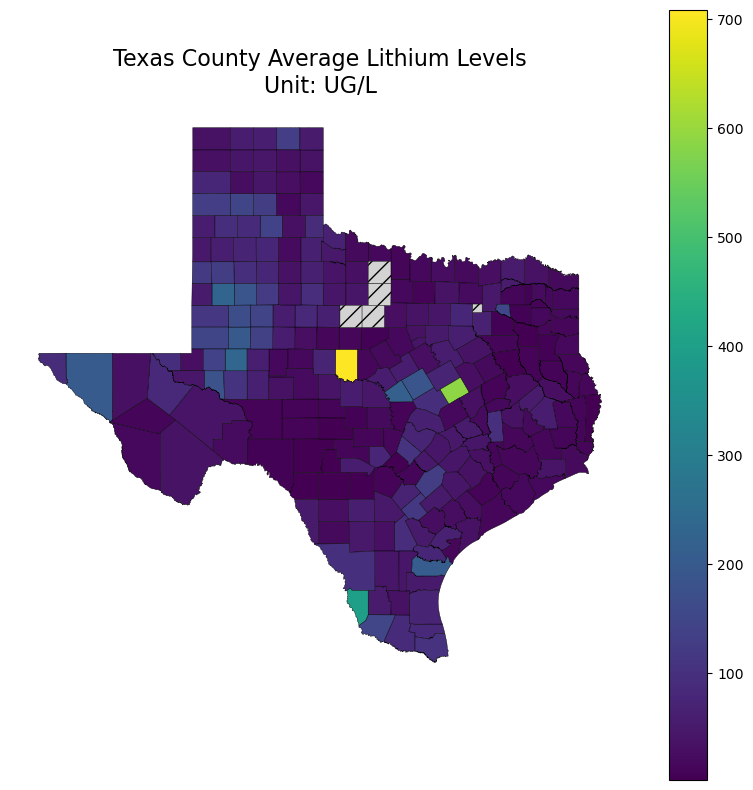

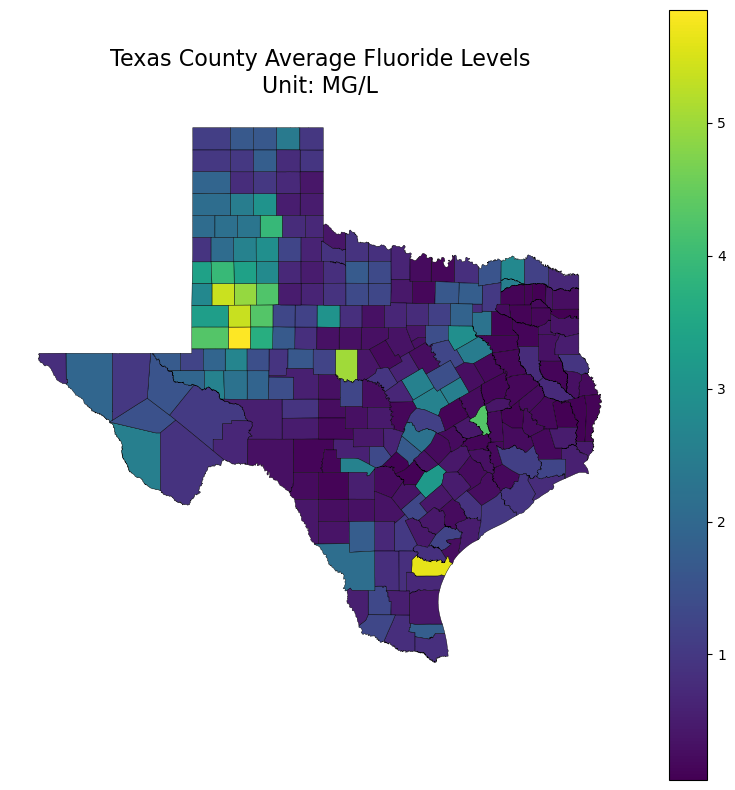

In [13]:
plot_contaminant_map("lead")
plot_contaminant_map("arsenic")
plot_contaminant_map("mercury")
plot_contaminant_map("lithium")
plot_contaminant_map("fluoride")
plot_contaminant_map("manganese")
plot_contaminant_map("uranium")
plot_contaminant_map("radium-226")
plot_contaminant_map("radium-228")
plot_contaminant_map("chromium")

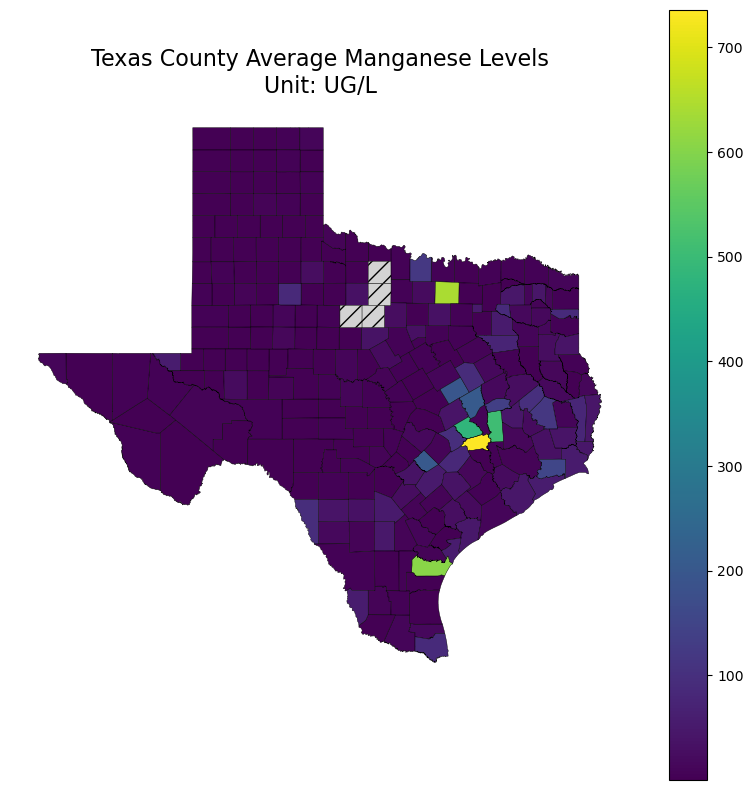

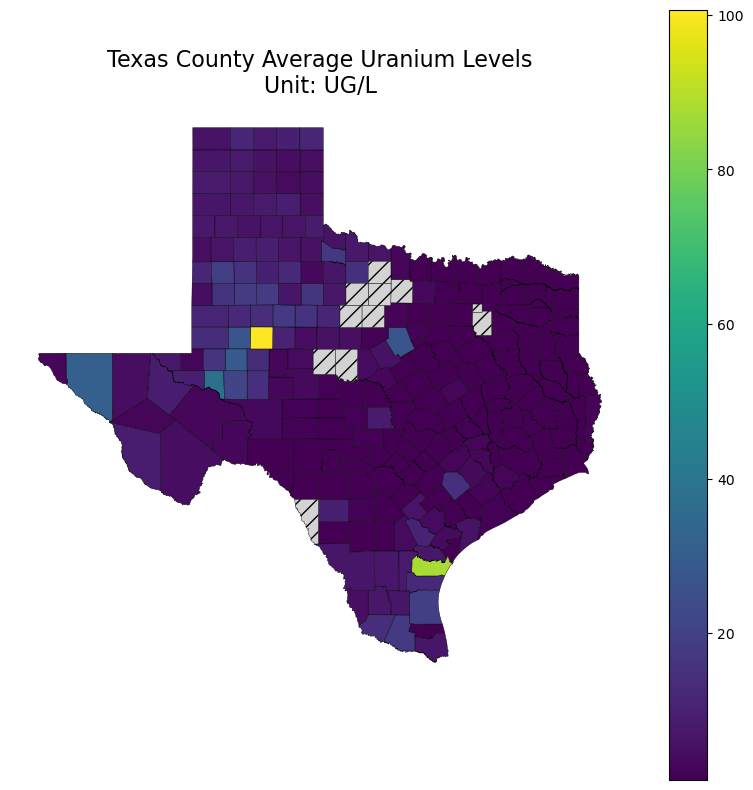

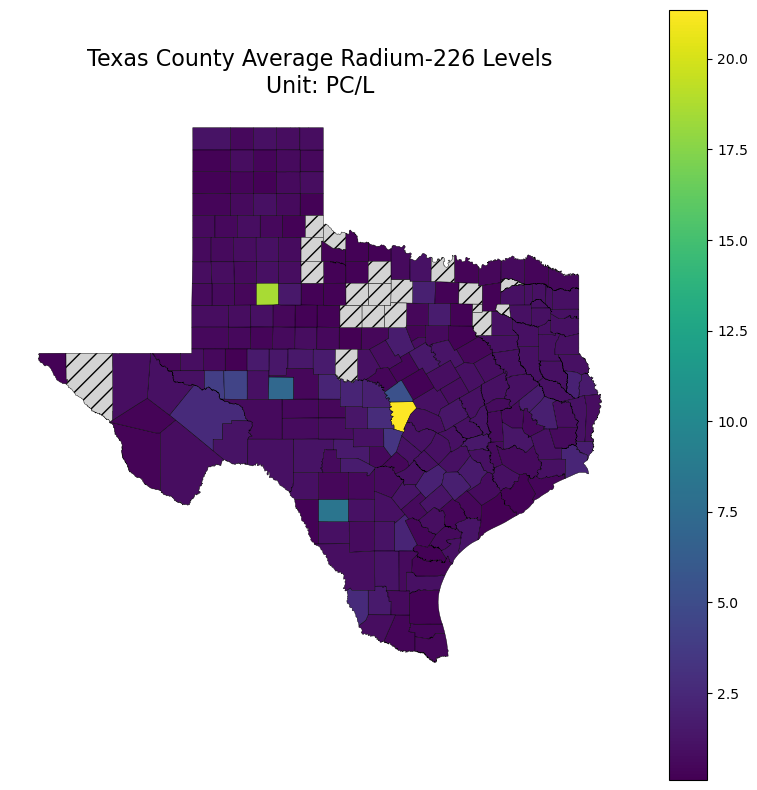

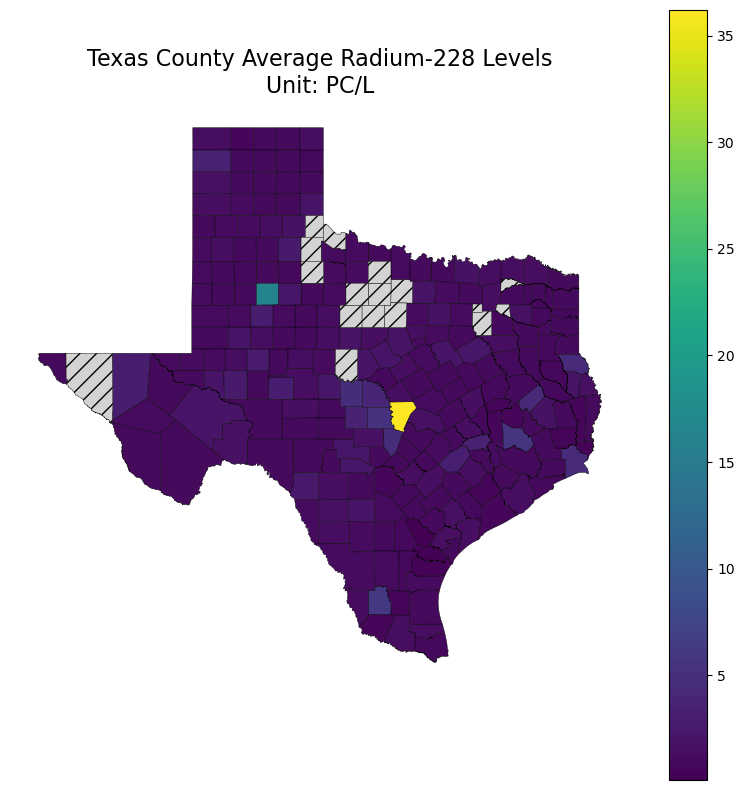

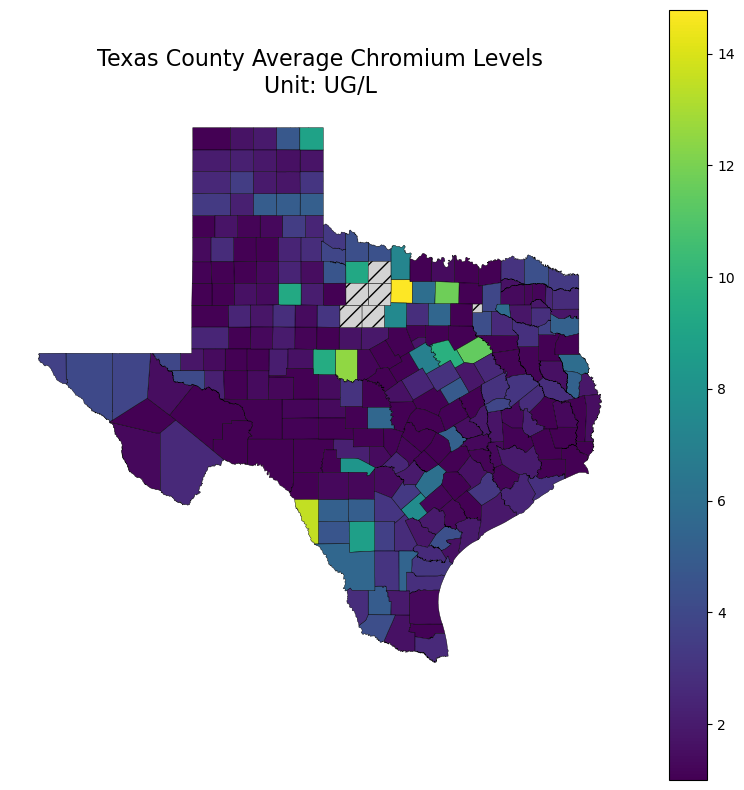

In [12]:
plot_contaminant_map("manganese")
plot_contaminant_map("uranium")
plot_contaminant_map("radium-226")
plot_contaminant_map("radium-228")
plot_contaminant_map("chromium")

In [ ]:
import matplotlib.pyplot as plt

def plot_contaminant_map(contaminant, wide_df=wide_df_avg, gdf=tx_counties):
    value_col = f"{contaminant}_avg"
    unit_col = f"{contaminant}_unit"

    if value_col not in wide_df.columns:
        raise ValueError(f"Contaminant '{contaminant}' not found. "
                         f"Available: {[c.replace('_avg','') for c in wide_df.columns if c.endswith('_avg')]}")

    # Merge map data + contaminant averages
    merged = gdf.merge(wide_df, left_on="NAME", right_on="County", how="left")

    # Extract unit (if available)
    unit = merged[unit_col].dropna().unique()
    unit = unit[0] if len(unit) > 0 else ""

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    merged.plot(column=value_col,
                ax=ax,
                legend=True,
                cmap="plasma",
                missing_kwds={"color": "lightgrey", "hatch": "//", "label": "No data"},
                edgecolor="black",
                linewidth=0.3)

    ax.set_title(f"Texas County Average {contaminant.capitalize()} Levels\nUnit: {unit}", fontsize=16)
    ax.set_axis_off()
    plt.show()

In [ ]:
plot_contaminant_map("lithium")